In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import geopandas as gpd
import shapely.geometry as point
import seaborn as sns
import os
from pathlib import Path


In [3]:
cwd=os.getcwd()
curr_dir=Path(cwd).parent
data_dir=os.path.join(curr_dir,"data")
df=pd.read_csv(os.path.join(data_dir,"train(1).csv"))


### Converting to geopandas dataframe 

In [3]:
gdf = gpd.GeoDataFrame(
    df,
    geometry=gpd.points_from_xy(df.long, df.lat),
    crs="EPSG:4326"
)


<Axes: >

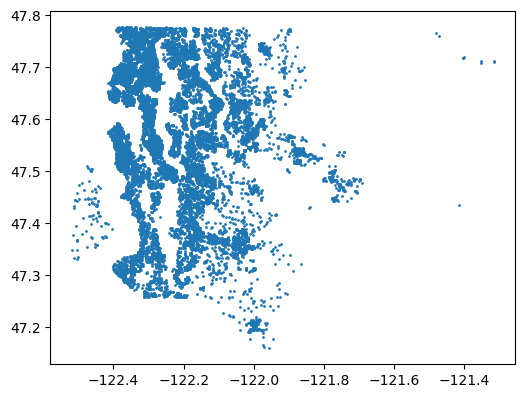

In [4]:
gdf.plot(figsize=(6,6), markersize=1)



### Creating a new feature living ratio to understand the effect of neighbours on prices


In [5]:
df["living_ratio"] = df["sqft_living"] / df["sqft_living15"]

### Normalising our features reated to sizes

In [4]:
from sklearn.preprocessing import StandardScaler

spatial_features = [
    "sqft_living",
    "sqft_living15",
    "sqft_lot",
    "sqft_lot15",
    "lat",
    "long",
    "sqft_above",
    "sqft_basement"
]

scaler = StandardScaler()
df[spatial_features] = scaler.fit_transform(df[spatial_features])
df

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,9117000170,20150505T000000,268643,4,2.25,-0.290276,-0.144952,2.0,0,0,...,7,0.030720,-0.657843,1961,0,98055,-0.900034,0.192759,-0.473911,-0.129791
1,6700390210,20140708T000000,245000,3,2.50,-0.521813,-0.311135,2.0,0,0,...,7,-0.224818,-0.657843,1992,0,98031,-1.137139,0.192759,-0.385919,-0.339019
2,7212660540,20150115T000000,200000,4,2.50,-0.389506,-0.160457,2.0,0,0,...,8,-0.078796,-0.657843,1994,0,98003,-2.098571,-0.706669,-0.165941,-0.196068
3,8562780200,20150427T000000,352499,2,2.25,-0.918734,-0.364787,2.0,0,0,...,7,-0.772399,-0.452638,2009,0,98027,-0.206791,1.006527,-1.089851,-0.445025
4,7760400350,20141205T000000,232000,3,2.00,-0.874632,-0.038936,1.0,0,0,...,7,-0.614209,-0.657843,1994,0,98042,-1.367738,0.999388,-0.576568,-0.173196
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16204,5272200045,20141113T000000,378000,3,1.50,-1.183348,-0.204862,1.0,0,0,...,7,-0.954927,-0.657843,1947,0,98125,1.111021,-0.749499,-1.441817,-0.214930
16205,9578500790,20141111T000000,399950,3,2.50,1.117691,-0.254109,2.0,0,0,...,8,1.584635,-0.657843,2014,0,98023,-1.903393,-0.963648,1.384176,-0.280428
16206,7202350480,20140930T000000,575000,3,2.50,0.051517,-0.259827,2.0,0,0,...,7,0.407943,-0.657843,2004,0,98053,0.869579,1.299198,-0.429915,-0.374478
16207,1723049033,20140620T000000,245000,1,0.75,-1.866934,0.003408,1.0,0,0,...,5,-1.709372,-0.657843,1963,0,98168,-0.576183,-0.778052,-1.192508,0.084078


### plotting the price distribution to understand if log of prices is needed

In [7]:
df["log_price"]=np.log1p(df["price"])

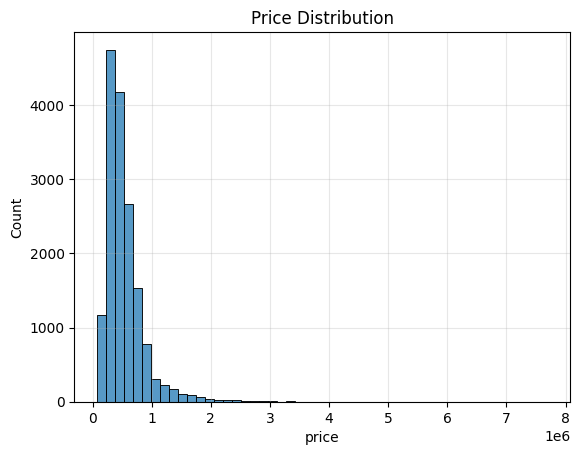

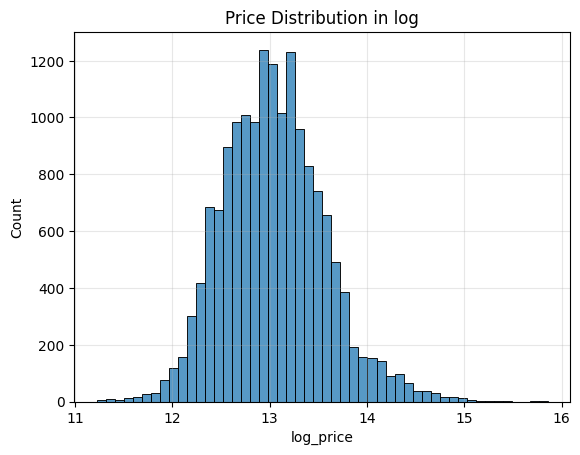

In [8]:

sns.histplot(df["price"], bins=50)
plt.title("Price Distribution")
plt.grid(alpha=0.3)
plt.show()
sns.histplot(df["log_price"], bins=50)
plt.title("Price Distribution in log")
plt.grid(alpha=0.3)
plt.show()

In [9]:
prices = np.array(df["price"])
np.median(prices)


np.float64(450000.0)

### plotting distribution og sqft_living with prices

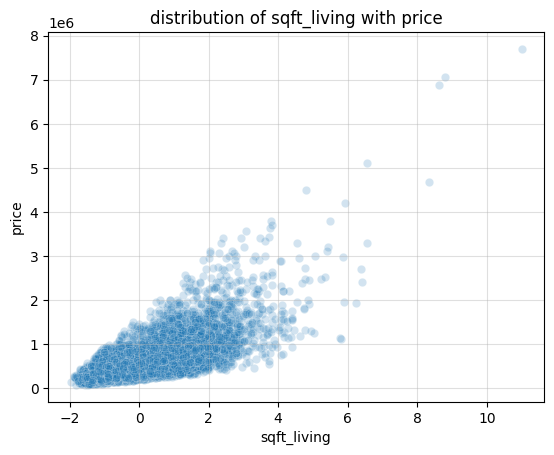

In [10]:
sns.scatterplot(x="sqft_living",y="price",data=df,alpha=0.2)
# plt.scatter(prices, sqft, alpha=0.3)
plt.ylabel("price")
plt.xlabel("sqft_living")
plt.title("distribution of sqft_living with price")
plt.grid(alpha=0.4)
plt.show()


### Plotting the distribution of 15 neighbours with prices

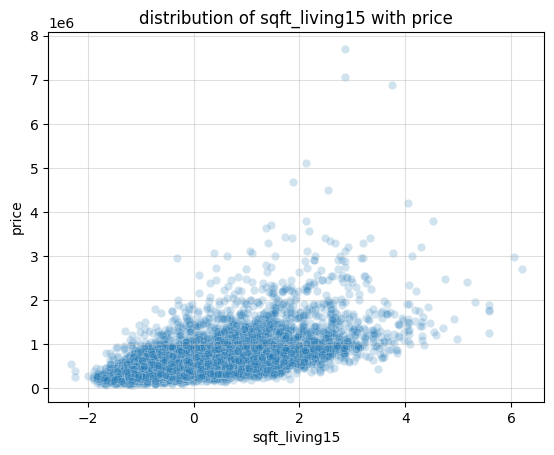

In [11]:
sns.scatterplot(x="sqft_living15",y="price",data=df,alpha=0.2)
plt.ylabel("price")
plt.xlabel("sqft_living15")
plt.title("distribution of sqft_living15 with price")
plt.grid(alpha=0.4)
plt.show()


### plotting the distibution of grades with prices

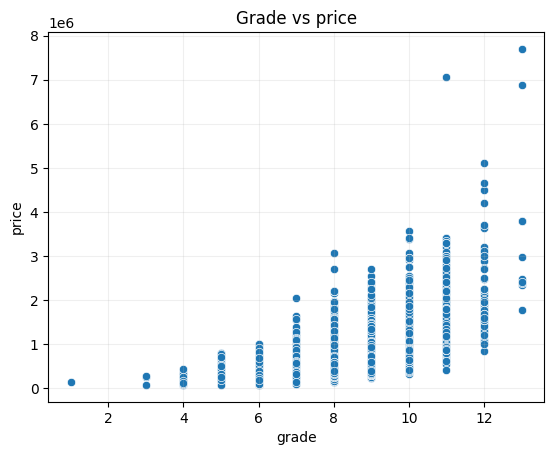

In [12]:
sns.scatterplot(x="grade",y="price",data=df)
plt.title("Grade vs price")
plt.grid(alpha=0.2)
plt.show()

### plotting the distibution of conditions with prices

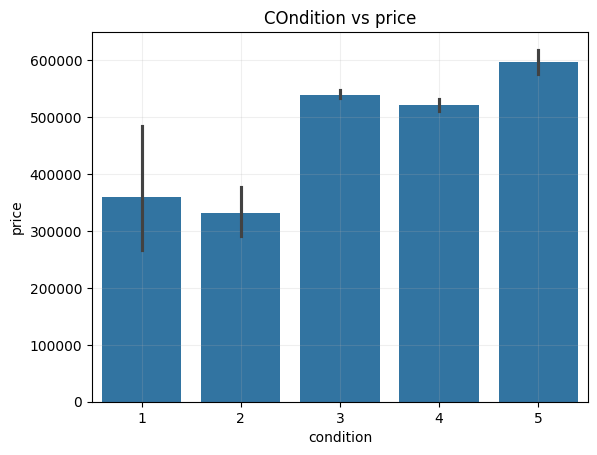

In [14]:
sns.barplot(x="condition",y="price",data=df)
plt.title("COndition vs price")
plt.grid(alpha=0.2)
plt.show()

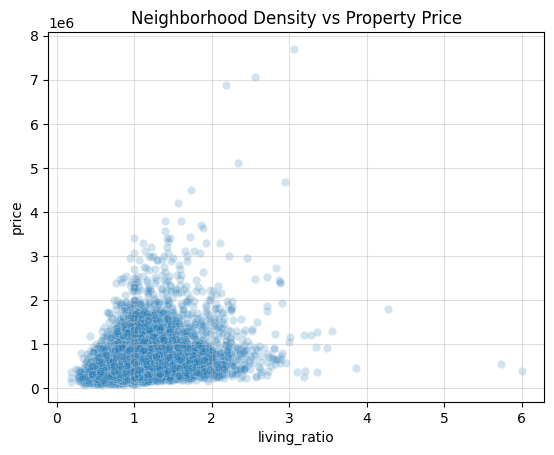

In [15]:
sns.scatterplot(x="living_ratio", y="price", data=df, alpha=0.2)
plt.title("Neighborhood Density vs Property Price")

plt.grid(alpha=0.4)
plt.show()

### finding correlation betweeen different features 

<Axes: >

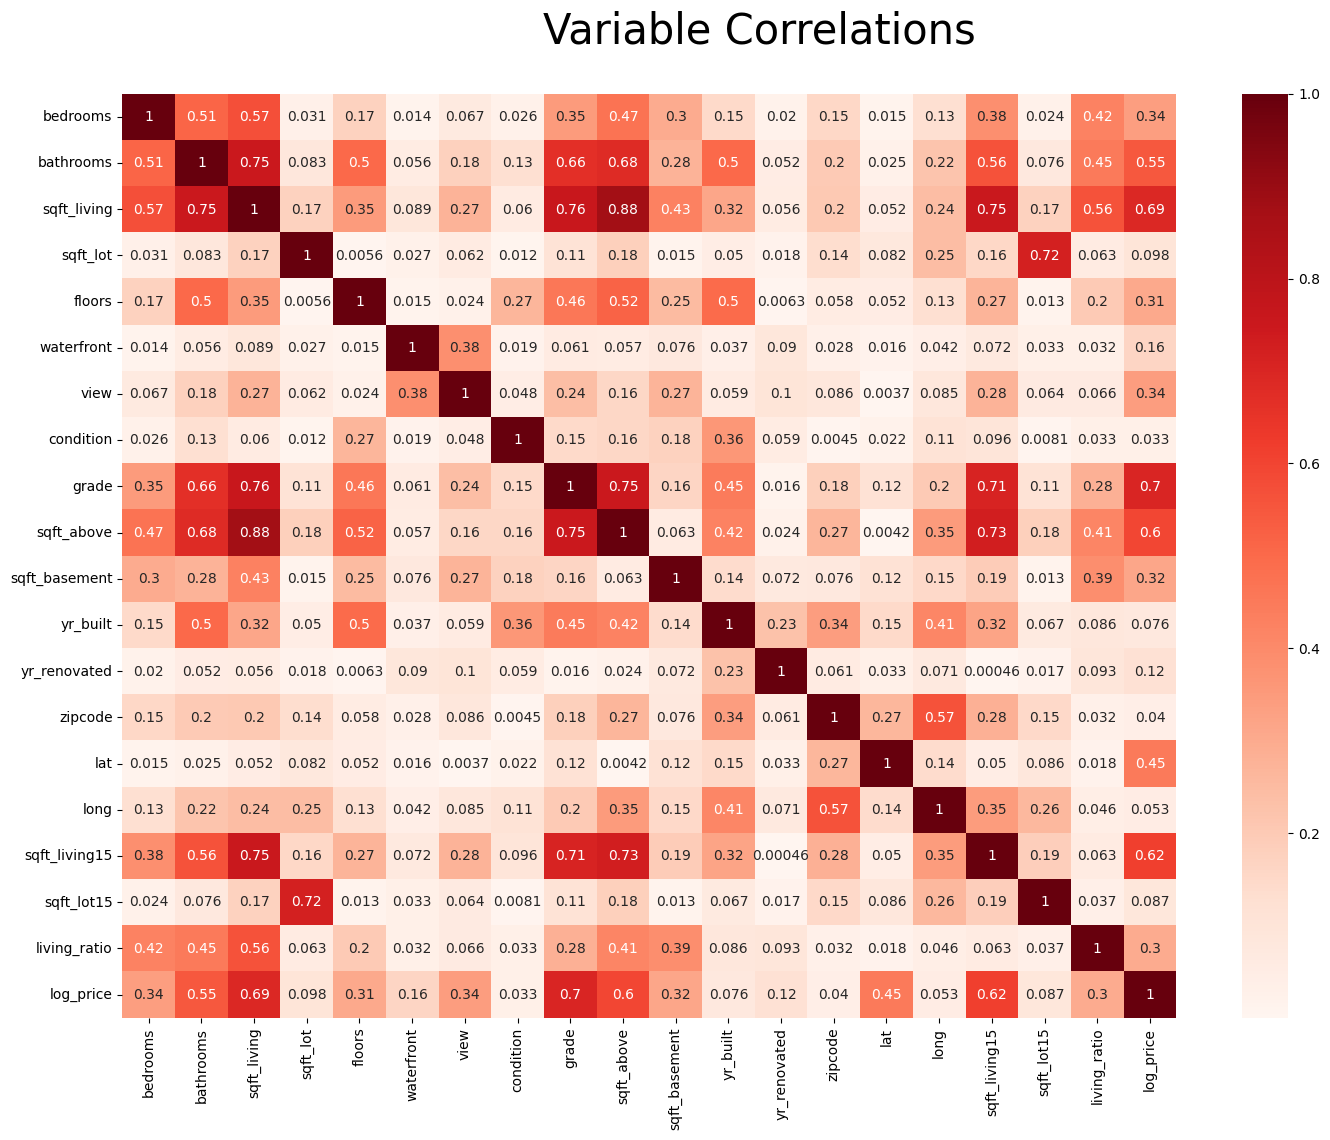

In [18]:
df1=df.drop(["date","id","price"],axis=1)


corr = df1.corr().abs()
fig, ax=plt.subplots(figsize=(17,12))
fig.suptitle('Variable Correlations', fontsize=30, y=.95)
heatmap = sns.heatmap(corr, cmap='Reds', annot=True)
heatmap

In [19]:
log_price=df["log_price"]

### finding the correlation of different feaures with log_prices

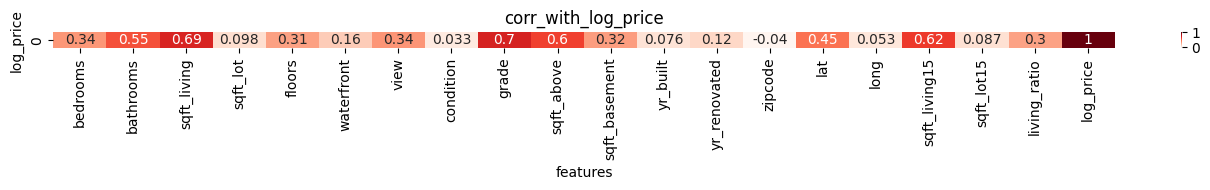

In [20]:
# compute correlation between each column in df1 and log_price
corr_with_price = df1.corrwith(log_price)

# seaborn.heatmap expects 2D input; convert Series to DataFrame and transpose so log_price is a row
corr_df = corr_with_price.to_frame().T

fig, ax = plt.subplots(figsize=(14,2))
heatmap = sns.heatmap(corr_df, cmap='Reds', annot=True, cbar=True)
ax.set_xlabel('features')
ax.set_ylabel('log_price')
ax.set_title("corr_with_log_price")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()


### Creating an array of directory of our images

In [5]:
from PIL import Image
from tqdm import tqdm
import io
from PIL import UnidentifiedImageError
def numeric_key(filename):
    return int(filename.split('_')[1].split('.')[0])
img_dir=os.path.join(curr_dir,"images")
img_array=[]
for file in sorted(os.listdir(img_dir),key=numeric_key):
    file_path=os.path.join(img_dir,file)
    img_array.append(file_path)


### Creating an array of directory of our test_images

In [22]:
test_img_dir=os.path.join(curr_dir,"test_images")
test_img_array=[]
for file in sorted(os.listdir(test_img_dir),key=numeric_key):
    file_path=os.path.join(test_img_dir,file)
    test_img_array.append(file_path)

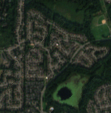

In [23]:
image_path = os.path.join(img_dir, img_array[464])
image=Image.open(image_path).convert("RGB")
image

### Using ResNet50 to generate embeddings for our image array

In [6]:
import torch
import torchvision.models as models
import torchvision.transforms.v2 as transforms

from torchvision.models import ResNet50_Weights

model = models.resnet50(weights=ResNet50_Weights.IMAGENET1K_V1)   #u sing resnet50 model 
model=torch.nn.Sequential(*list(model.children())[:-1])  # removing its final layer 

model.eval()
# transforming our image according to resnet 50 
transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToImage(), 
    transforms.ToDtype(torch.float32, scale=True),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

def extract_embeddings(image):
    image=transform(image).unsqueeze(0)
    with torch.inference_mode():
        embedding=model(image)
    return embedding.squeeze().numpy()

In [ ]:
## generating embeddings and storing it in a dict with directory as keys and embeddings of images as value
image_embeddings_dict={}
corrupted_files=[]
for file in tqdm(img_array):
    try:
        image=Image.open(file).convert("RGB")
        embeddings=extract_embeddings(image)
        image_embeddings_dict[file]=embeddings
    except UnidentifiedImageError:
        corrupted_files.append(file)

In [ ]:
## generating embeddings and storing it in a dict with directory as keys and embeddings of test_images as value
test_image_embeddings_dict={}
test_corrupted_files=[]
for file in tqdm(test_img_array):
    try:
        image=Image.open(file).convert("RGB")
        embeddings=extract_embeddings(image)
        test_image_embeddings_dict[file]=embeddings
    except UnidentifiedImageError:
        test_corrupted_files.append(file)

## Checking if there is a corrupted file

In [ ]:
if corrupted_files!=[]:
    for file in corrupted_files:
        try:
            os.remove(file)
            print(f"deleted {file}")
        except OSError as e:
            print(f"Error deleting {file}: {e}")
else:
    print("There is no corrupted files")

In [ ]:
if test_corrupted_files!=[]:
    for file in corrupted_files:
        try:
            os.remove(file)
            print(f"deleted {file}")
        except OSError as e:
            print(f"Error deleting {file}: {e}")
else:
    print("There is no corrupted files")

## exporting our embeddings as a pickle file 

In [ ]:
import pickle
from pathlib import Path
embedding_dir=os.path.join(curr_dir,"embeddings")
path = os.path.join(embedding_dir, "image_embeddings.pickle")


if not os.path.exists(path):
    with open(path,"wb") as handle:
        pickle.dump(image_embeddings_dict,handle,protocol=pickle.HIGHEST_PROTOCOL)

In [ ]:
import pickle
from pathlib import Path
test_path = os.path.join(embedding_dir, "test_image_embeddings.pickle")

if not os.path.exists(test_path):
    with open(test_path,"wb") as handle:
        pickle.dump(test_image_embeddings_dict,handle,protocol=pickle.HIGHEST_PROTOCOL)

### We will open the embeddings we generated to understand grad-cam and visualise the different embeddings 


In [6]:
import pickle

embedding_dir=os.path.join(curr_dir,"embeddings")

path=os.path.join(embedding_dir,"image_embeddings.pickle")
with open(path,"rb") as handle:
    image_embeddings=pickle.load(handle)

### seperating embeddings and images

In [7]:
vectors=[]
images=[]
for image,embedding in image_embeddings.items():
    vectors.append(embedding)
    images.append(image)

### Using PCA to change the dimension from 2048 to 128

In [15]:
from sklearn.decomposition import PCA

PCA_DIM = 128  

pca = PCA(
    n_components=PCA_DIM,
    random_state=42
)
vectors_pca=pca.fit_transform(vectors)

print("Explained variance:", pca.explained_variance_ratio_.sum())

Explained variance: 0.9108844605961782


### We will now find the 9 nearest neighbours of each picture using dot products between them 

In [16]:
from sklearn.neighbors import NearestNeighbors

nbrs=NearestNeighbors(n_neighbors=9, metric='cosine').fit(vectors_pca)
nbrs

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",9
,"radius radius: float, default=1.0Range of parameter space to use by default for :meth:`radius_neighbors`queries.",1.0
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'cosine'
,"p p: float (positive), default=2Parameter for the Minkowski metric fromsklearn.metrics.pairwise.pairwise_distances. When p = 1, this isequivalent to using manhattan_distance (l1), and euclidean_distance(l2) for p = 2. For arbitrary p, minkowski_distance (l_p) is used.",2
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None


### We will find distances between each neigbhour and indices of each pictures

In [17]:
neighbor_distances, neighbor_indices = nbrs.kneighbors(vectors_pca)
neighbor_similarities = 1 - neighbor_distances
neighbor_similarities, neighbor_indices

(array([[1.        , 0.85601105, 0.85481042, ..., 0.80184358, 0.77861093,
         0.7785255 ],
        [1.        , 0.9484649 , 0.91772761, ..., 0.81444968, 0.81292792,
         0.78959399],
        [1.        , 0.81920331, 0.78731905, ..., 0.75029229, 0.72688058,
         0.71456247],
        ...,
        [1.        , 0.90499783, 0.90113422, ..., 0.86342715, 0.85665704,
         0.85665704],
        [1.        , 0.70449174, 0.68062582, ..., 0.62156589, 0.6155761 ,
         0.60845587],
        [1.        , 0.71289592, 0.69705374, ..., 0.58472658, 0.57975751,
         0.57910818]], shape=(16209, 9)),
 array([[    0,  7283,  1515, ..., 15513, 11585,  6763],
        [    1, 14479, 14280, ...,   786,  2431, 11929],
        [    2,  6357,  7465, ...,   505, 13579,  9625],
        ...,
        [16206, 14748,  4878, ...,  4505,  3430, 12407],
        [16207,   519, 12120, ...,  2468, 10918, 15610],
        [16208, 12359,  9180, ...,  8058, 15636,  5497]], shape=(16209, 9)))

In [19]:
neighborhoods_dict = {}
for i in range(len(neighbor_indices)):
    center_image=images[neighbor_indices[i, 0]]
    neighbors_list=[]
    for j in range(0, len(neighbor_indices[0])):
        neighbor_image=images[neighbor_indices[i][j]]
        neighbor_similarity=round(neighbor_similarities[i][j],2)
        neighbors_list.append([neighbor_image, neighbor_similarity])
    neighborhoods_dict[center_image]=neighbors_list


In [20]:
len(neighborhoods_dict)

15756

In [21]:
images_with_full_path = list(neighborhoods_dict.keys())
(images_with_full_path)

['d:\\cdc project\\images\\property_0.png',
 'd:\\cdc project\\images\\property_1.png',
 'd:\\cdc project\\images\\property_2.png',
 'd:\\cdc project\\images\\property_10191.png',
 'd:\\cdc project\\images\\property_4.png',
 'd:\\cdc project\\images\\property_5.png',
 'd:\\cdc project\\images\\property_6.png',
 'd:\\cdc project\\images\\property_7.png',
 'd:\\cdc project\\images\\property_8.png',
 'd:\\cdc project\\images\\property_6861.png',
 'd:\\cdc project\\images\\property_10.png',
 'd:\\cdc project\\images\\property_11.png',
 'd:\\cdc project\\images\\property_12.png',
 'd:\\cdc project\\images\\property_13.png',
 'd:\\cdc project\\images\\property_14.png',
 'd:\\cdc project\\images\\property_15.png',
 'd:\\cdc project\\images\\property_16.png',
 'd:\\cdc project\\images\\property_17.png',
 'd:\\cdc project\\images\\property_18.png',
 'd:\\cdc project\\images\\property_19.png',
 'd:\\cdc project\\images\\property_9403.png',
 'd:\\cdc project\\images\\property_21.png',
 'd:\\cdc p

### Visualisng 9 neighbours of a picture using a function

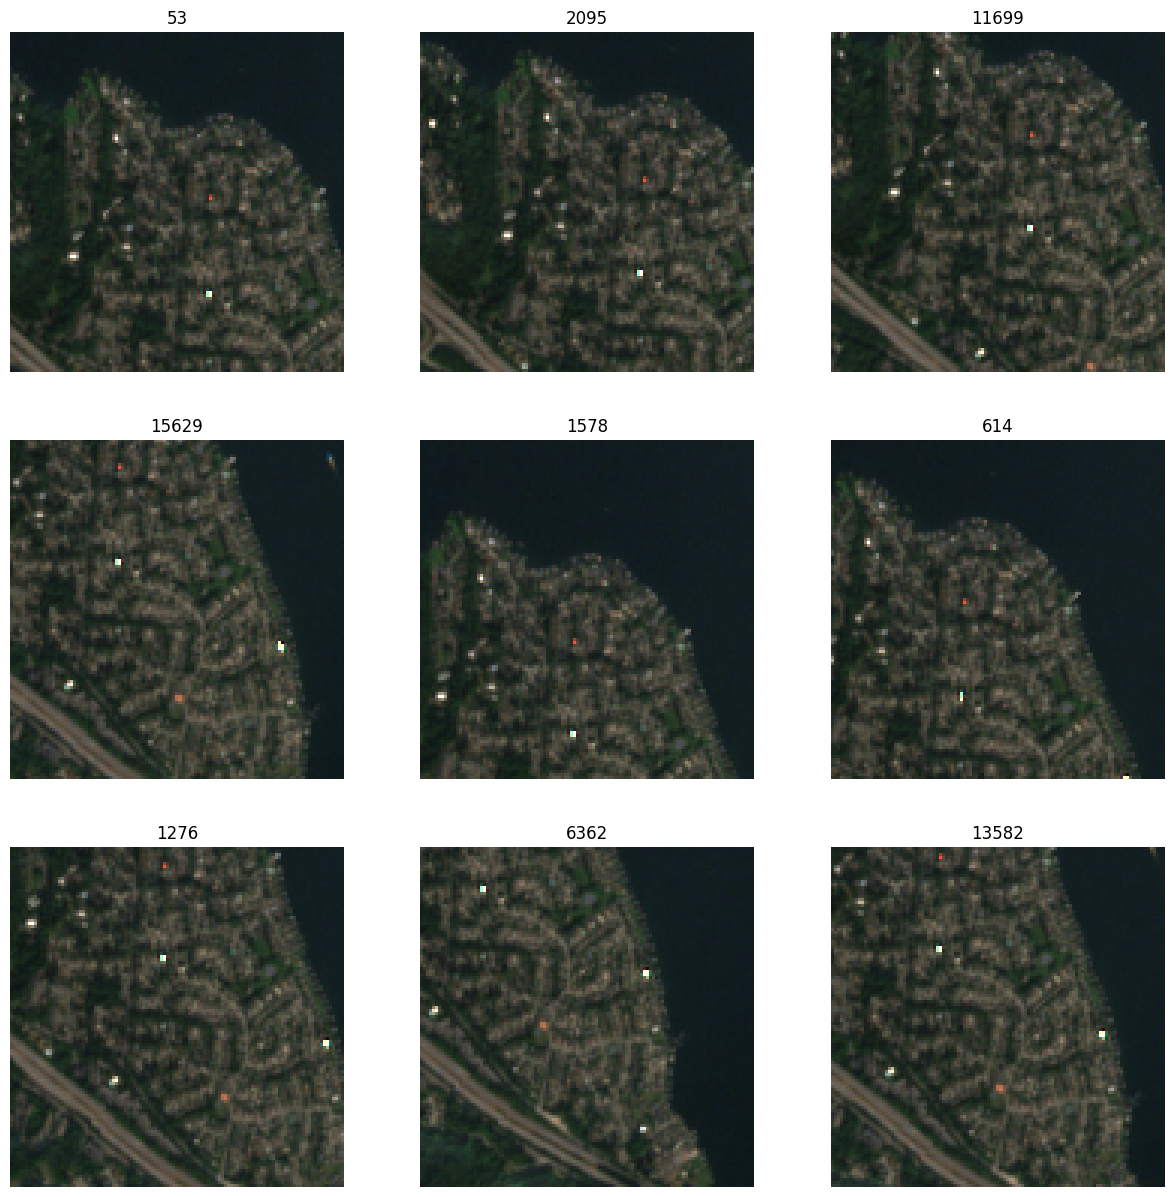

In [22]:
import skimage.io as io
img_dir=os.path.join(curr_dir,"images")

def plot_neighborhood(neighbors_row,indices):

  f, axarr = plt.subplots(3,3, figsize=(15,15))

  axarr[0][0].imshow(io.imread(neighbors_row[0][0]))
  axarr[0][1].imshow(io.imread(neighbors_row[1][0]))
  axarr[0][2].imshow(io.imread(neighbors_row[2][0]))
  axarr[1][0].imshow(io.imread(neighbors_row[3][0]))
  axarr[1][1].imshow(io.imread(neighbors_row[4][0]))
  axarr[1][2].imshow(io.imread(neighbors_row[5][0]))
  axarr[2][0].imshow(io.imread(neighbors_row[6][0]))
  axarr[2][1].imshow(io.imread(neighbors_row[7][0]))
  axarr[2][2].imshow(io.imread(neighbors_row[8][0]))

  axarr[0, 0].set_title(indices[0])
  axarr[0, 1].set_title(indices[1])
  axarr[0, 2].set_title(indices[2])
  axarr[1, 0].set_title(indices[3])
  axarr[1, 1].set_title(indices[4])
  axarr[1, 2].set_title(indices[5])
  axarr[2, 0].set_title(indices[6])
  axarr[2, 1].set_title(indices[7])
  axarr[2, 2].set_title(indices[8])

  for i in range(3):
        for j in range(3):
            axarr[i, j].axis('off')
slider=53                   ### THese allow us to use every 1620 photos
plot_neighborhood(neighborhoods_dict[images_with_full_path[slider]],neighbor_indices[slider])

In [58]:
price=df["price"]
vectors_pca=np.array(vectors_pca)
corrs = np.corrcoef(vectors_pca.T, price)[-1, :-1]
top_dims = np.argsort(np.abs(corrs))[-10:]
bottom_dims = np.argsort(np.abs(corrs))[:10]


In [59]:
top_dims

array([14,  5, 39, 24, 22,  4, 15, 18,  8,  2])

In [60]:
bottom_dims

array([109,  10,  44,  77,  63, 112, 122,  81,  92, 116])

In [61]:
top_dim = top_dims[8]
bottom_dim=bottom_dims[8]

top_images = np.argsort(vectors[:, top_dim])[-6:]
bottom_images=np.argsort(vectors[:,bottom_dim])[-6:]

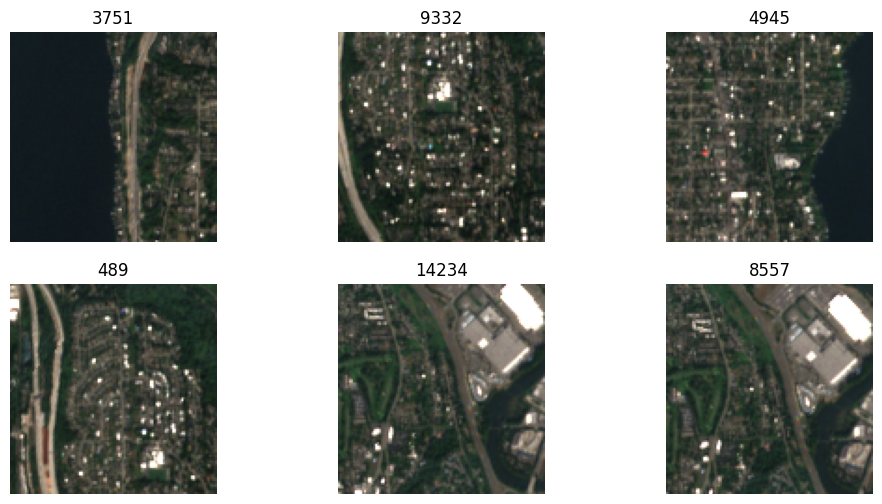

In [62]:
f, axarr = plt.subplots(2,3, figsize=(12,6))
axarr[0][0].imshow(io.imread(images[top_images[0]]))
axarr[0][1].imshow(io.imread(images[top_images[1]]))
axarr[0][2].imshow(io.imread(images[top_images[2]]))
axarr[1][0].imshow(io.imread(images[top_images[3]]))
axarr[1][1].imshow(io.imread(images[top_images[4]]))
axarr[1][2].imshow(io.imread(images[top_images[5]]))
axarr[0, 0].set_title(top_images[0])
axarr[0, 1].set_title(top_images[1])
axarr[0, 2].set_title(top_images[2])
axarr[1, 0].set_title(top_images[3])
axarr[1, 1].set_title(top_images[4])
axarr[1, 2].set_title(top_images[5])
for i in range(2):
        for j in range(3):
            axarr[i, j].axis('off')


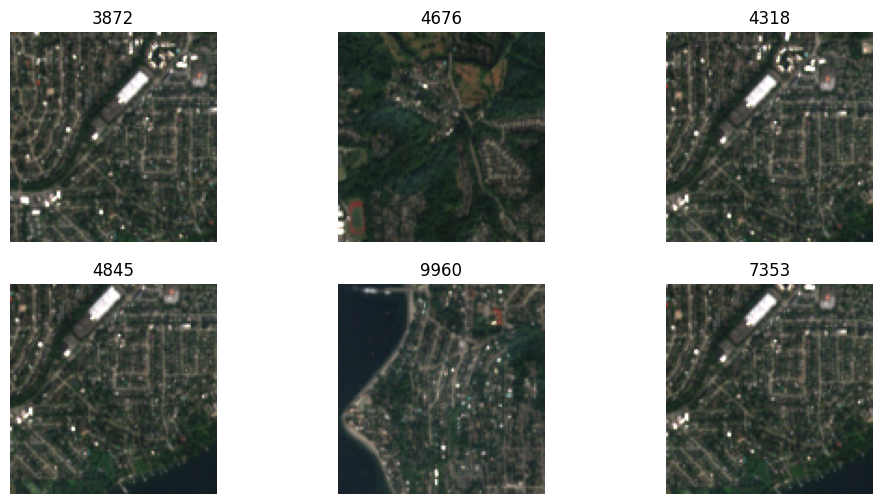

In [63]:
f, axarr = plt.subplots(2,3, figsize=(12,6))
axarr[0][0].imshow(io.imread(images[bottom_images[0]]))
axarr[0][1].imshow(io.imread(images[bottom_images[1]]))
axarr[0][2].imshow(io.imread(images[bottom_images[2]]))
axarr[1][0].imshow(io.imread(images[bottom_images[3]]))
axarr[1][1].imshow(io.imread(images[bottom_images[4]]))
axarr[1][2].imshow(io.imread(images[bottom_images[5]]))
axarr[0, 0].set_title(bottom_images[0])
axarr[0, 1].set_title(bottom_images[1])
axarr[0, 2].set_title(bottom_images[2])
axarr[1, 0].set_title(bottom_images[3])
axarr[1, 1].set_title(bottom_images[4])
axarr[1, 2].set_title(bottom_images[5])
for i in range(2):
        for j in range(3):
            axarr[i, j].axis('off')


In [7]:
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image
from torchvision.models import resnet50
import torch
from PIL import Image
import cv2

model = resnet50(pretrained=True)
device = "cuda" if torch.cuda.is_available() else "cpu"
model.fc = torch.nn.Identity()
model.eval()
import torchvision.transforms as T

target_layers = [model.layer4[-1]]
transform = T.Compose([
    T.Resize((224, 224)),
    T.ToTensor(),
    T.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])
## importing CAM and then using it 
cam = GradCAM(
    model=model,
    target_layers=target_layers,
)



c:\Users\user\AppData\Local\Programs\Python\Python312\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\user\AppData\Local\Programs\Python\Python312\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [65]:

from pytorch_grad_cam.utils.image import show_cam_on_image
#defining a function to us grad_cam on a image

def grad_cam_transform(
    rank_images,
    percentile=75,
    blur_kernel=(11, 11),
    alpha=0.55,
    add_contours=True
):
    cam_images = []

    for rank_image in rank_images:
        # Load image
        img = Image.open(os.path.join(images[rank_image])).convert("RGB")
        img_resized = img.resize((224, 224))
        rgb_img = np.array(img_resized).astype(np.float32) / 255.0

        # Model input
        input_tensor = transform(img).unsqueeze(0).to(device)

        # Grad-CAM
        grayscale_cam = cam(input_tensor=input_tensor)[0]

        # Robust normalization (percentile-based)
        cam_low, cam_high = np.percentile(grayscale_cam, [5, 99])
        cam_norm = np.clip((grayscale_cam - cam_low) / (cam_high - cam_low + 1e-8), 0, 1)

        # Smooth heatmap 
        cam_smooth = cv2.GaussianBlur(cam_norm, blur_kernel, 0)

        # Soft thresholding (keeps structure, removes noise)
        thresh = np.percentile(cam_smooth, percentile)
        cam_masked = cam_smooth * (cam_smooth >= thresh)

        # Overlay heatmap
        cam_image = show_cam_on_image(
            rgb_img,
            cam_masked,
            colormap=cv2.COLORMAP_INFERNO,
            image_weight=alpha,
            use_rgb=True
        )
        # Adiing contours on the graph 

        if add_contours:
            contours, _ = cv2.findContours(
                (cam_masked > thresh).astype(np.uint8),
                cv2.RETR_EXTERNAL,
                cv2.CHAIN_APPROX_SIMPLE
            )
            cam_image = cv2.drawContours(
                cam_image,
                contours,
                -1,
                (255, 255, 255),
                1
            )

        cam_images.append(cam_image)

    return cam_images






In [66]:
cam_top_images=grad_cam_transform(top_images)
cam_bottom_images=grad_cam_transform(bottom_images)
len(cam_top_images)

6

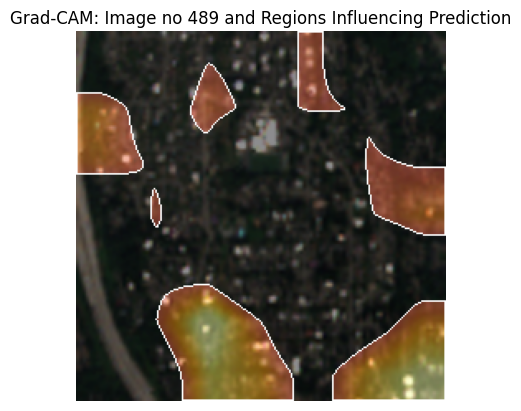

In [67]:

cam_image=cam_top_images[1]
plt.imshow(cam_image)
plt.axis("off")
plt.title(f"Grad-CAM: Image no {top_images[3]} and Regions Influencing Prediction")
plt.show()


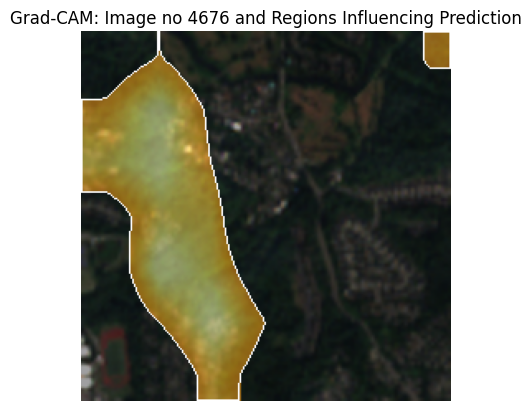

In [68]:
cam_image=cam_bottom_images[1]
plt.imshow(cam_image)
plt.axis("off")
plt.title(f"Grad-CAM: Image no {bottom_images[1]} and Regions Influencing Prediction")
plt.show()